In [14]:
!pip install geopandas

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

out_dir = Path("/mnt/gsdata/projects/panops/panops-data-registry/data/flux/fluxnet_2017_2025_V02")


metadata_file = sorted(out_dir.glob("selected_sites_igbp_*.csv"))[-1]

metadata = pd.read_csv(metadata_file)

print("Number of selected sites:", metadata["site_id"].nunique())

metadata.head()

Number of selected sites: 357


,data_hub,site_id,site_name,location_lat,location_long,igbp,network,team_member_name,team_member_role,team_member_email,first_year,last_year,download_link,fluxnet_product_name,product_citation,product_id,oneflux_code_version,product_source_network,max_consecutive_years_2017_2025
0,AmeriFlux,AR-TF1,Rio Moat bog,-54.9733,-66.7335,WET,AmeriFlux,Lars Kutzbach;Veronica Pancotto;David Holl,PI;PI;DataManager,lars.kutzbach@uni-hamburg.de;pancotto@cadic-co...,2016,2018,https://ftp.fluxdata.org/.ameriflux_downloads/...,AMF_AR-TF1_FLUXNET_2016-2018_v1.3_r1.zip,"Lars Kutzbach (2025), AmeriFlux FLUXNET-1F AR-...",10.17190/AMF/1818370,v1.3,AMF,2
1,AmeriFlux,AR-TF2,Rio Pipo bog,-54.8269,-68.4549,WET,AmeriFlux,Lars Kutzbach;Veronica Pancotto;David Holl,PI;PI;DataManager,lars.kutzbach@uni-hamburg.de;pancotto@cadic-co...,2016,2018,https://ftp.fluxdata.org/.ameriflux_downloads/...,AMF_AR-TF2_FLUXNET_2016-2018_v1.3_r1.zip,"Lars Kutzbach (2025), AmeriFlux FLUXNET-1F AR-...",10.17190/AMF/2571120,v1.3,AMF,2
2,AmeriFlux,BR-ITA,MataFLUX: Multi-species tree restoration planting,-23.0604,-48.6467,EBF,AmeriFlux,Joannès Guillemot;Guerric le Maire;Pedro Branc...,PI;AncContact;AncContact,joannes.guillemot@cirad.fr;guerric.le_maire@ci...,2020,2024,https://ftp.fluxdata.org/.ameriflux_downloads/...,AMF_BR-ITA_FLUXNET_2020-2024_v1.3_r1.zip,"Joannès Guillemot (2026), AmeriFlux FLUXNET-1F...",10.17190/AMF/3027371,v1.3,AMF,5
3,AmeriFlux,BR-Npw,Northern Pantanal Wetland,-16.4980,-56.4120,WSA,AmeriFlux,Higo Dalmagro;Mark Johnson;George Vourlitis;Pa...,PI;PI;AncContact;AncContact,higojdalmagro@gmail.com;mark.johnson@ubc.ca;ge...,2013,2017,https://ftp.fluxdata.org/.ameriflux_downloads/...,AMF_BR-Npw_FLUXNET_2013-2017_v1.3_r1.zip,"George Vourlitis, Higo Dalmagro, José de S. N...",10.17190/AMF/1881563,v1.3,AMF,1
4,AmeriFlux,CA-ARB,Attawapiskat River Bog,52.6950,-83.9452,WET,AmeriFlux,Elyn Humphreys;Phaedra Cowden,PI;DataManager,elynhumphreys@cunet.carleton.ca;phaedracowden@...,2011,2024,https://ftp.fluxdata.org/.ameriflux_downloads/...,AMF_CA-ARB_FLUXNET_2011-2024_v1.3_r1.zip,"Aaron Todd, Elyn Humphreys (2025), AmeriFlux F...",10.17190/AMF/1902821,v1.3,AMF,8


In [3]:
site_metadata = metadata[
    [
        "site_id",
        "site_name",
        "igbp",
        "location_lat",
        "location_long",
        "first_year",
        "last_year",
        "max_consecutive_years_2017_2025"
    ]
].drop_duplicates()

site_metadata = site_metadata.sort_values(["igbp", "site_id"])

site_metadata.head()

,site_id,site_name,igbp,location_lat,location_long,first_year,last_year,max_consecutive_years_2017_2025
253,BE-Maa,Maasmechelen,CSH,50.979870,5.631851,2016,2024,8
298,ES-Crg,Caroig,CSH,39.119260,-0.958520,2021,2024,4
286,ES-MtN,MonteNegro,CSH,36.992340,-6.482602,2024,2024,1
213,IT-Noe,Arca di Noe - Le Prigionette,CSH,40.606174,8.151694,2022,2024,3
49,US-EA5,Uvalde Ranch Mesquite Woodland,CSH,29.358400,-99.957600,2021,2022,2


In [ ]:

site_metadata_file = out_dir / "fluxnet_site_metadata_clean.csv"

site_metadata.to_csv(site_metadata_file, index=False)

print("Saved:", site_metadata_file)

Saved: /mnt/gsdata/projects/panops/panops-data-registry/data/flux/fluxnet_2017_2025_V02/fluxnet_site_metadata_clean.csv


In [5]:
n_sites = site_metadata["site_id"].nunique()

print(f"Total number of sites: {n_sites}")

Total number of sites: 357


In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
site_metadata = pd.read_csv("Flux4Daniel/fluxnet_site_metadata_clean_with_elevation.csv")

/home/nk1125/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


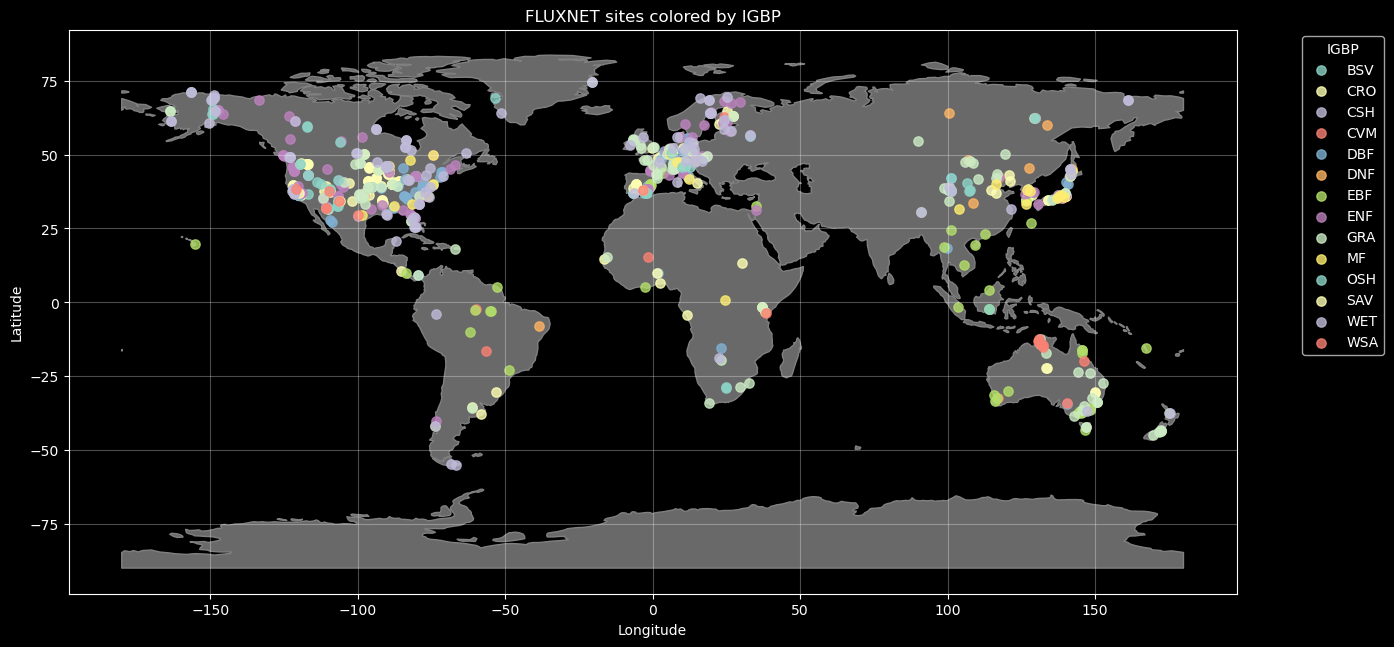

In [3]:
import geopandas as gpd
from geodatasets import get_path
import matplotlib.pyplot as plt

# Dark theme
plt.style.use("dark_background")
# Load world map
world = gpd.read_file(get_path("naturalearth.land"))

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Plot land
world.plot(
    ax=ax,
    color="dimgray",
    edgecolor="gray"
)

# Plot FLUXNET sites
for igbp, group in site_metadata.groupby("IGBP"):
    ax.scatter(
        group["LOCATION_LONG"],
        group["LOCATION_LAT"],
        label=igbp,
        s=45,
        alpha=0.8
    )

# Labels and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

ax.set_title("FLUXNET sites colored by IGBP")

# Legend
ax.legend(
    title="IGBP",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)
# Optional clean look

ax.grid(False)

# Remove axes completely for presentation style

#ax.set_axis_off()

# Grid
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

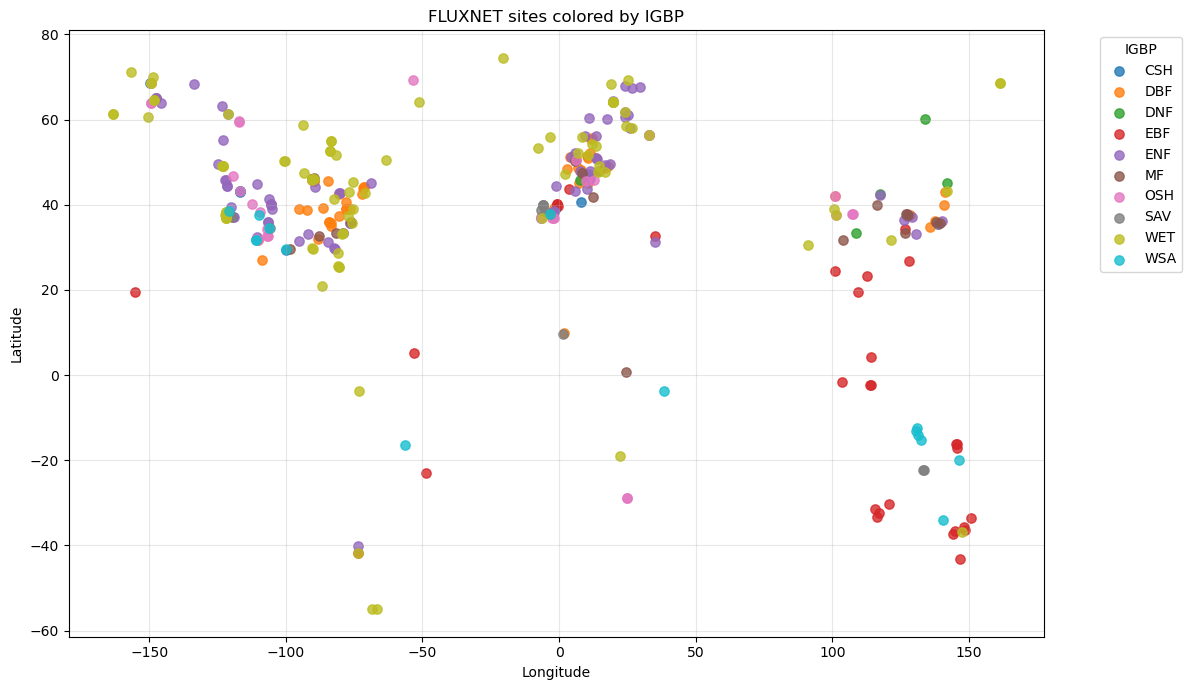

In [19]:
plt.figure(figsize=(12, 7))

for igbp, group in site_metadata.groupby("igbp"):
    plt.scatter(
        group["location_long"],
        group["location_lat"],
        label=igbp,
        s=45,
        alpha=0.8
    )

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("FLUXNET sites colored by IGBP")
plt.legend(title="IGBP", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

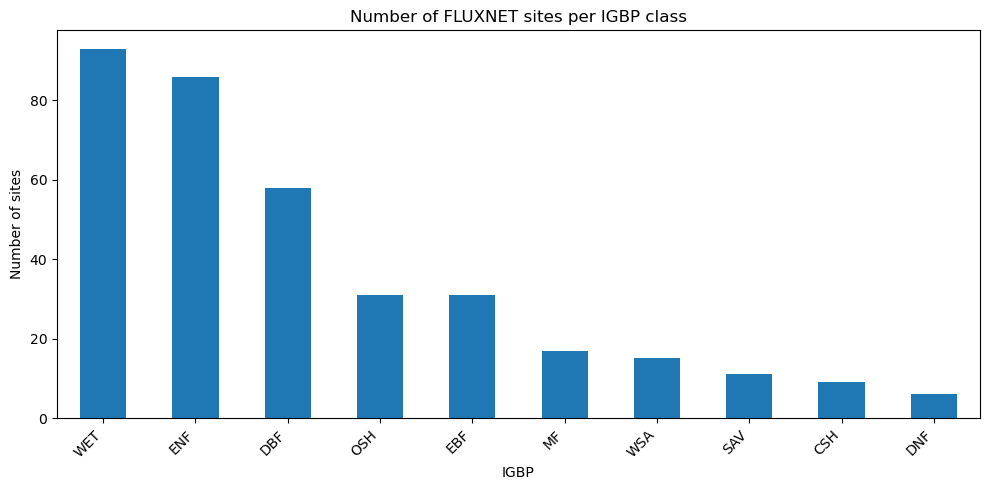

igbp
WET    93
ENF    86
DBF    58
OSH    31
EBF    31
MF     17
WSA    15
SAV    11
CSH     9
DNF     6
Name: count, dtype: int64

In [20]:
igbp_counts = site_metadata["igbp"].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
igbp_counts.plot(kind="bar")

plt.xlabel("IGBP")
plt.ylabel("Number of sites")
plt.title("Number of FLUXNET sites per IGBP class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

igbp_counts

In [21]:
continuity_summary = {}

for n in [2, 3, 4]:
    count = (
        site_metadata["max_consecutive_years_2017_2025"] >= n
    ).sum()
    
    continuity_summary[n] = count
    
    print(f"{count} sites have at least {n} continuous years")

324 sites have at least 2 continuous years
286 sites have at least 3 continuous years
258 sites have at least 4 continuous years


In [22]:
continuity_df = pd.DataFrame({
    "minimum_continuous_years": continuity_summary.keys(),
    "number_of_sites": continuity_summary.values()
})

continuity_df

,minimum_continuous_years,number_of_sites
0,2,324
1,3,286
2,4,258


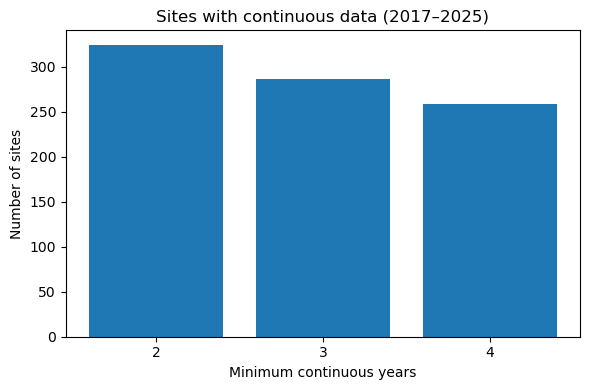

In [23]:
plt.figure(figsize=(6, 4))

plt.bar(
    continuity_df["minimum_continuous_years"].astype(str),
    continuity_df["number_of_sites"]
)

plt.xlabel("Minimum continuous years")
plt.ylabel("Number of sites")

plt.title("Sites with continuous data (2017–2025)")

plt.tight_layout()
plt.show()

In [24]:
import geopandas as gpd
from geodatasets import get_path
import matplotlib.pyplot as plt

world = gpd.read_file(get_path("naturalearth.land"))

def plot_continuous_year_outputs(min_years):
    subset_meta = site_metadata[
        site_metadata["max_consecutive_years_2017_2025"] >= min_years
    ].copy()

    selected_sites = subset_meta["site_id"].tolist()

    subset_availability = availability_df[
        availability_df["site_id"].isin(selected_sites)
    ].copy()

    site_year_matrix = (
        subset_availability
        .assign(available=1)
        .pivot_table(
            index="site_id",
            columns="year",
            values="available",
            fill_value=0
        )
        .reindex(columns=range(2017, 2026), fill_value=0)
    )

    igbp_counts = subset_meta["igbp"].value_counts().sort_values(ascending=False)

    print(f"\n===== At least {min_years} continuous years =====")
    print("Number of sites:", subset_meta["site_id"].nunique())
    print(igbp_counts)

    # 1. World map
    plt.style.use("dark_background")

    fig, ax = plt.subplots(figsize=(16, 8))
    fig.patch.set_facecolor("black")
    ax.set_facecolor("black")

    world.plot(ax=ax, color="dimgray", edgecolor="gray")

    for igbp, group in subset_meta.groupby("igbp"):
        ax.scatter(
            group["location_long"],
            group["location_lat"],
            s=60,
            alpha=0.9,
            label=igbp
        )

    ax.set_title(
        f"FLUXNET sites with ≥{min_years} continuous years of data (2017–2025)",
        fontsize=16
    )

    ax.legend(
        title="IGBP",
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        fontsize=8
    )

    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    # 2. Site-year matrix
    plt.style.use("default")

    plt.figure(figsize=(12, max(6, len(site_year_matrix) * 0.12)))

    plt.imshow(
        site_year_matrix,
        aspect="auto",
        interpolation="none"
    )

    plt.yticks(
        range(len(site_year_matrix.index)),
        site_year_matrix.index,
        fontsize=7
    )

    plt.xticks(
        range(len(site_year_matrix.columns)),
        site_year_matrix.columns,
        rotation=90
    )

    plt.xlabel("Year")
    plt.ylabel("Site")

    plt.title(
        f"Site-year availability matrix: ≥{min_years} continuous years"
    )

    plt.tight_layout()
    plt.show()

    # 3. IGBP bar plot
    plt.figure(figsize=(10, 5))

    igbp_counts.plot(kind="bar")

    plt.xlabel("IGBP")
    plt.ylabel("Number of sites")

    plt.title(
        f"Number of sites per IGBP: ≥{min_years} continuous years"
    )

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    return subset_meta, site_year_matrix, igbp_counts

In [ ]:
# Recreate availability_df from metadata

availability = []

for _, row in metadata.iterrows():

    start = max(int(row["first_year"]), 2017)
    end = min(int(row["last_year"]), 2025)

    for year in range(start, end + 1):

        availability.append({
            "site_id": row["site_id"],
            "igbp": row["igbp"],
            "year": year
        })

availability_df = pd.DataFrame(availability)

print(availability_df.shape)
availability_df.head()


===== At least 2 continuous years =====
Number of sites: 324
igbp
WET    88
ENF    78
DBF    46
OSH    30
EBF    30
MF     16
WSA    13
SAV     9
CSH     8
DNF     6
Name: count, dtype: int64


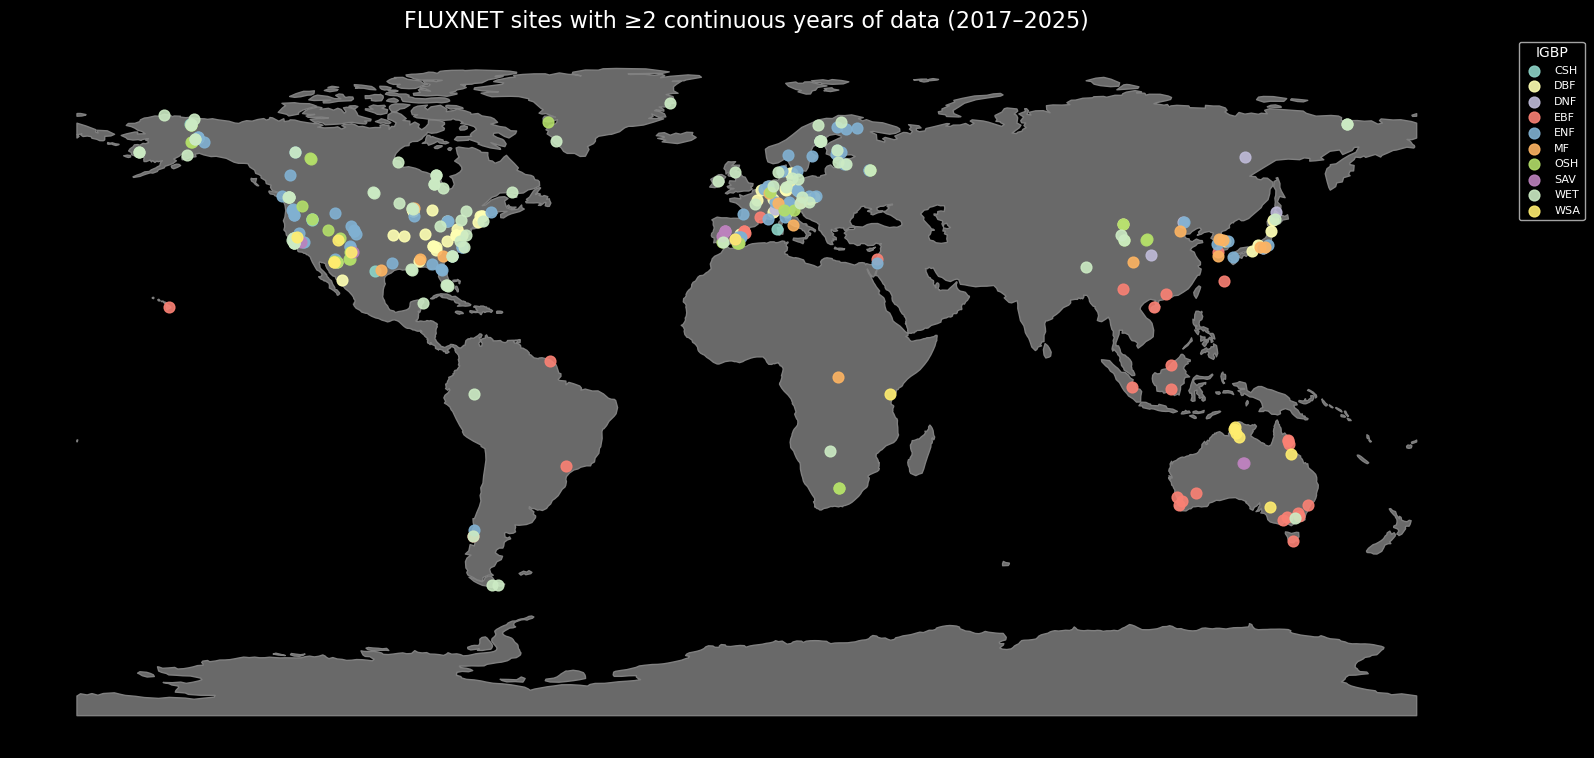

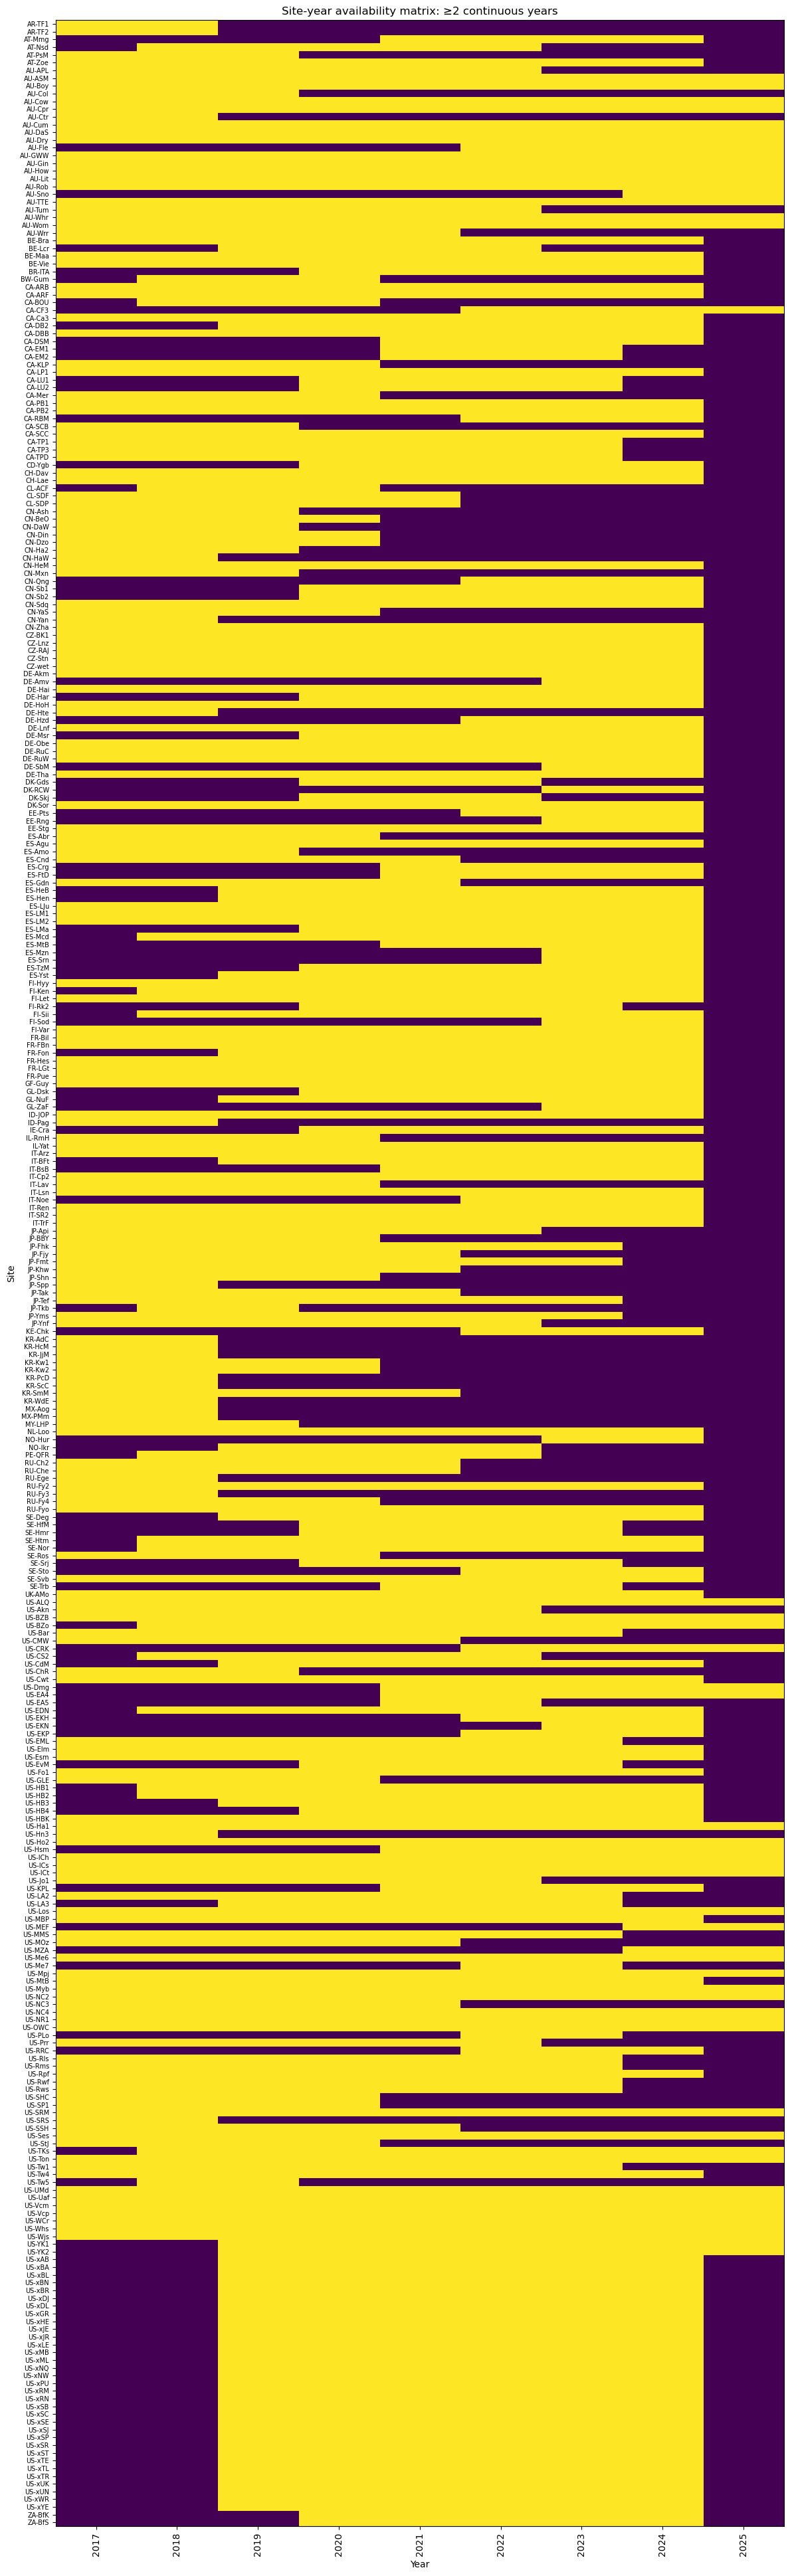

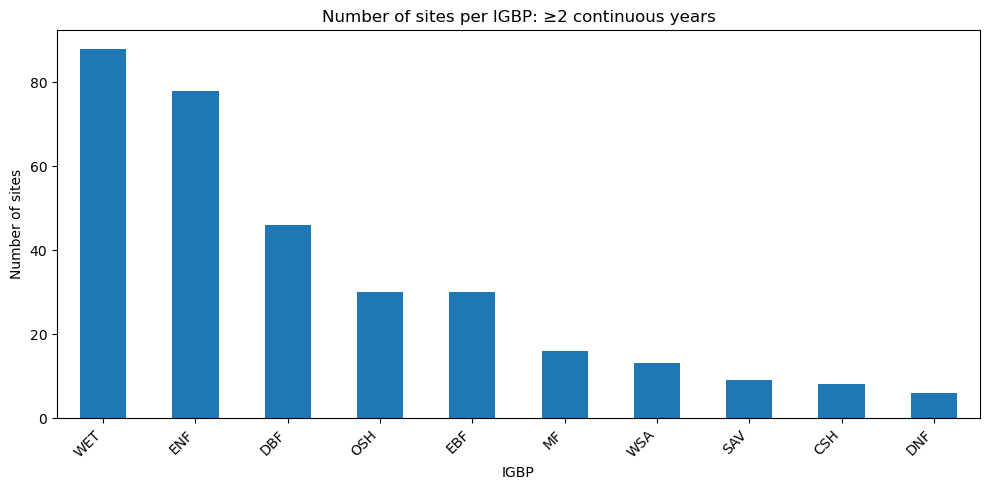


===== At least 3 continuous years =====
Number of sites: 286
igbp
WET    75
ENF    71
DBF    42
OSH    27
EBF    24
MF     14
WSA    12
SAV     9
CSH     7
DNF     5
Name: count, dtype: int64


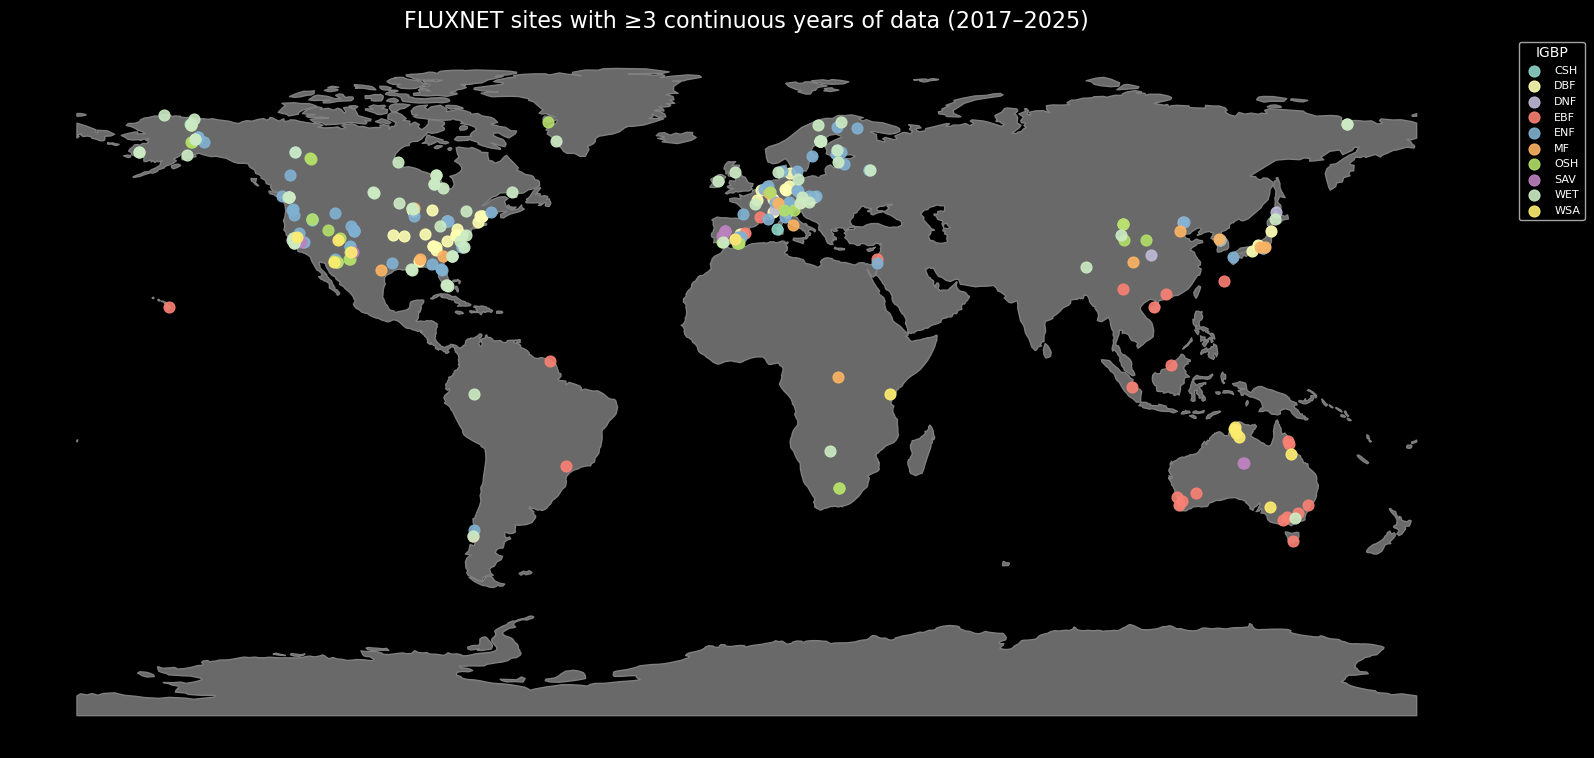

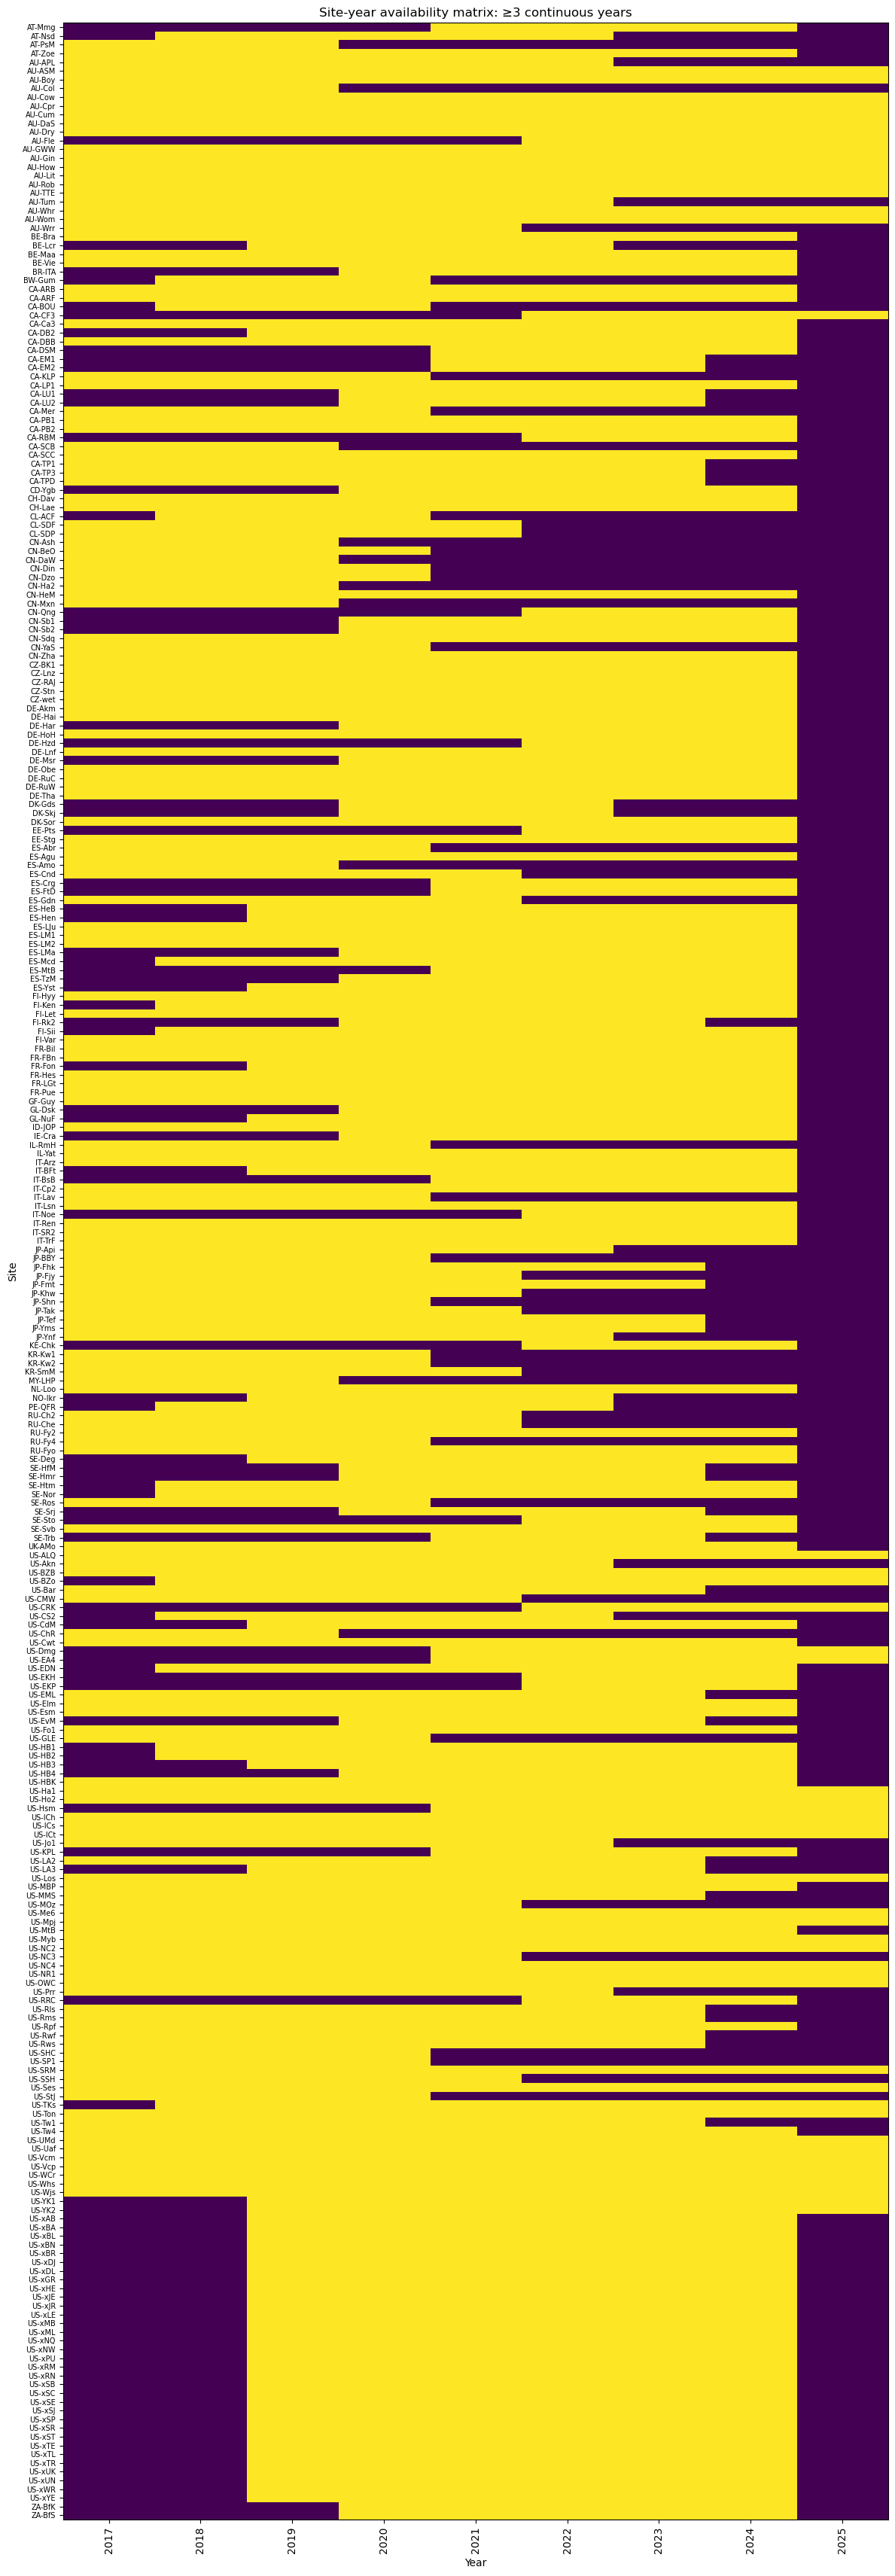

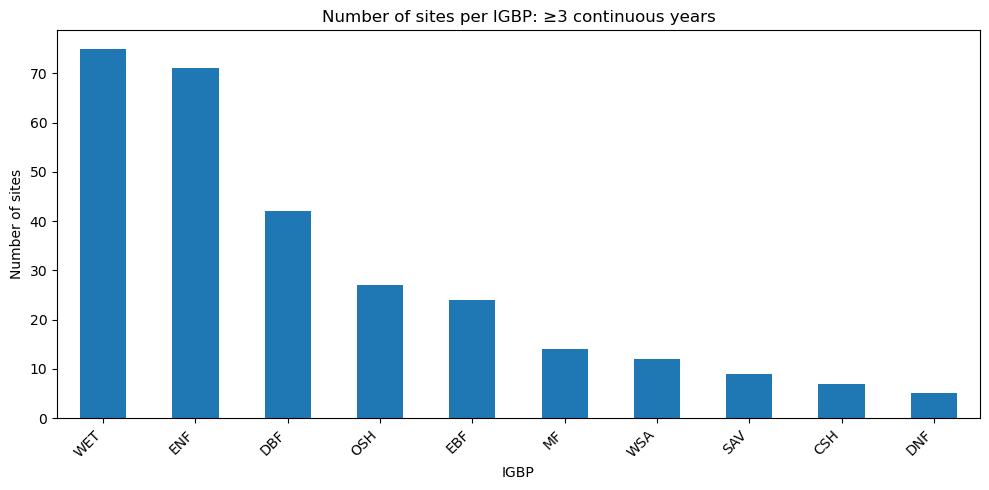


===== At least 4 continuous years =====
Number of sites: 258
igbp
ENF    69
WET    60
DBF    40
OSH    25
EBF    21
MF     13
WSA    11
SAV     9
CSH     6
DNF     4
Name: count, dtype: int64


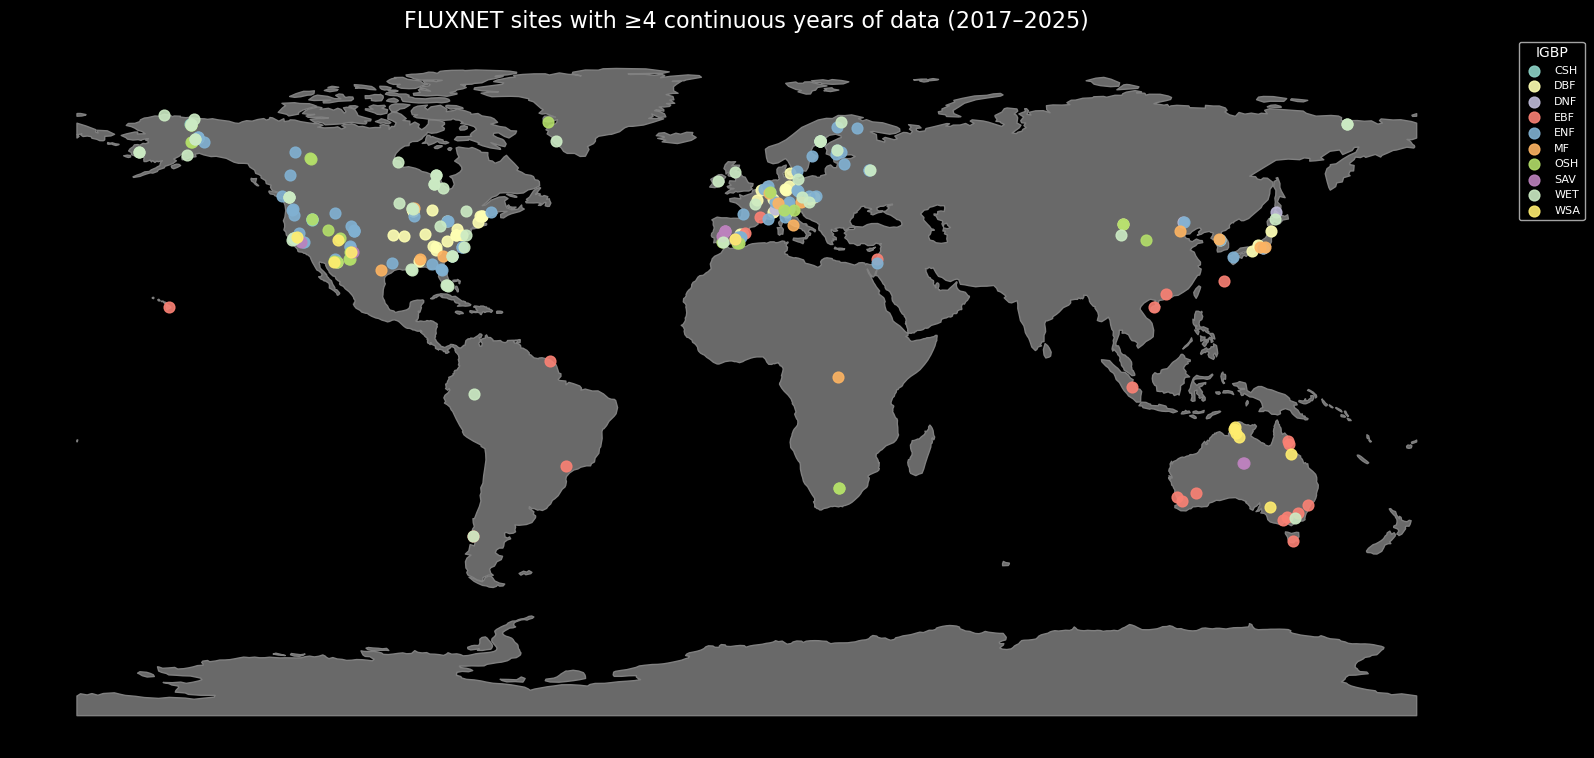

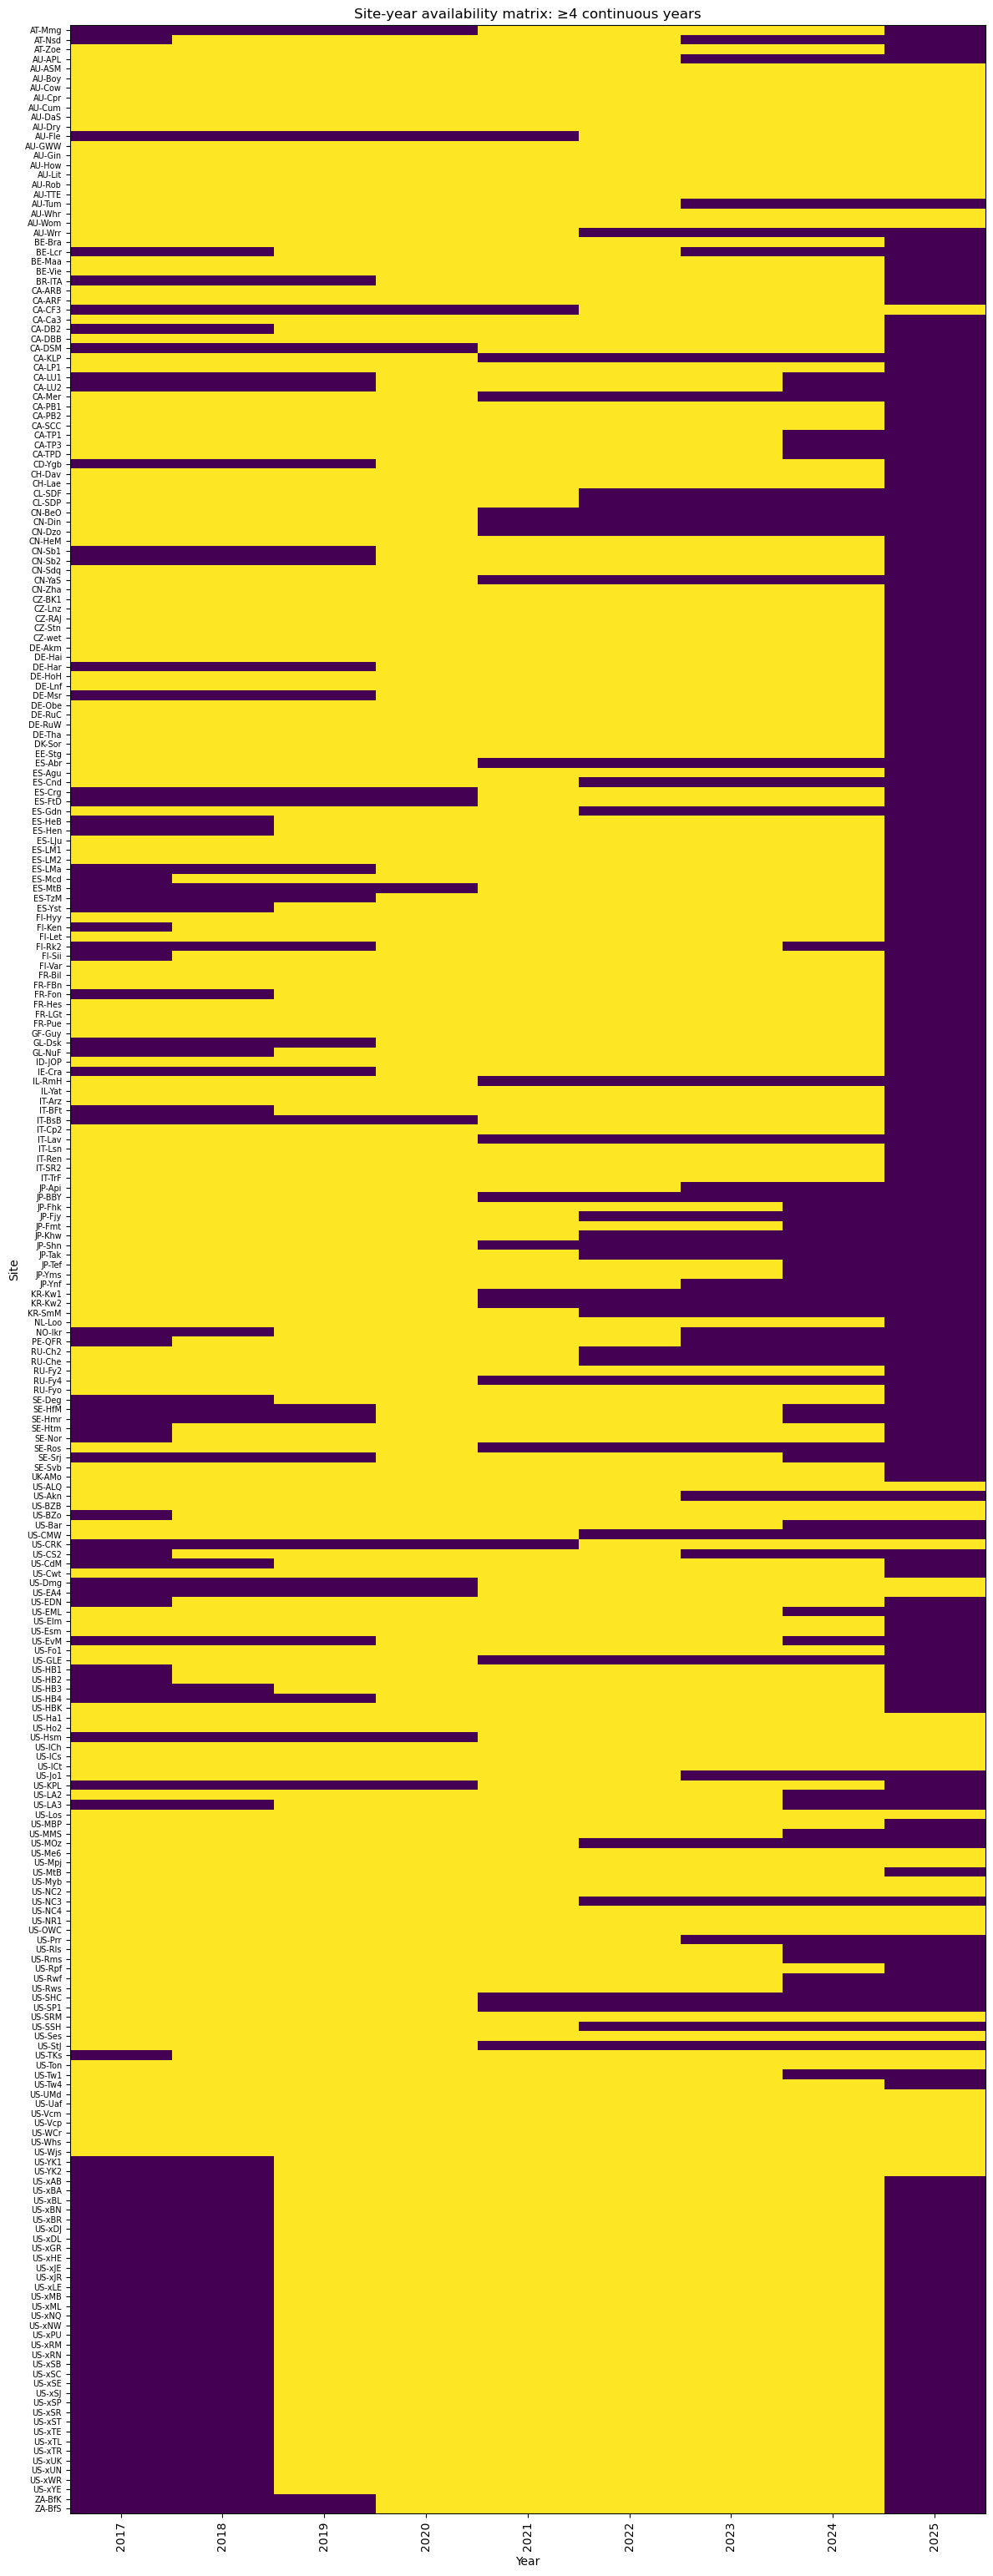

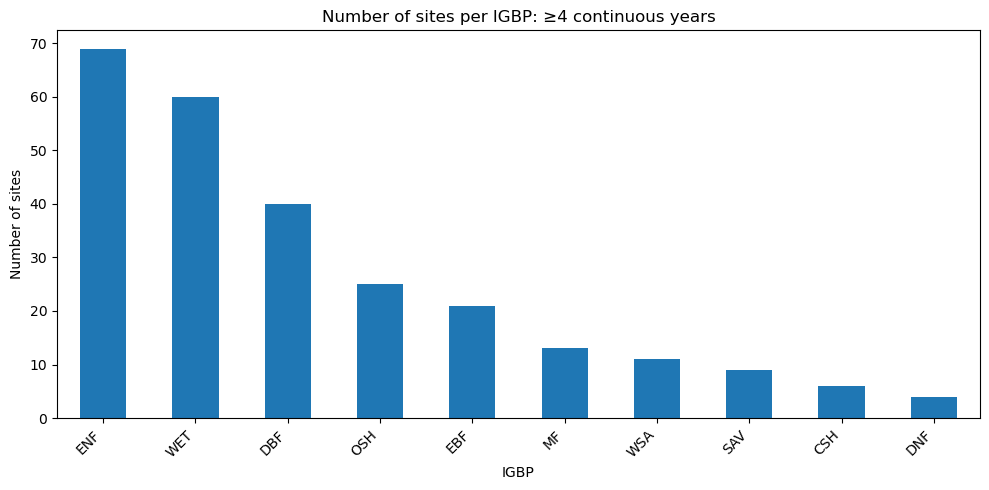

In [25]:
meta_2yr, matrix_2yr, igbp_2yr = plot_continuous_year_outputs(2)
meta_3yr, matrix_3yr, igbp_3yr = plot_continuous_year_outputs(3)
meta_4yr, matrix_4yr, igbp_4yr = plot_continuous_year_outputs(4)

In [5]:
from pathlib import Path

from geopandas import read_file
import pandas as pd
import matplotlib.pyplot as plt

all_efp_data = pd.read_csv("fluxnet_2017_2025_V02/EFP_outputs_corrected/ALL_SITES_YEARLY_EFP_corrected.csv")

all_efp_data





,SITE_ID,YEAR,uWUE,WUE,ETmax,precipAvail,Gavail,GSmax,CO2avail,G1,EF,EFampl,GPPsat,NEPmax,Rb,Rbmax,aCUE,TZ,nyears,status
0,AR-TF1,2017,1.372171,1.818027,0.182875,yes,no,0.004534,yes,2.148585,0.563796,0.272828,11.102377,8.869746,1.149991,1.262253,0.599777,-3.0,1,ok
1,AR-TF1,2018,2.294293,2.381346,0.164824,yes,no,0.005552,yes,2.767544,0.791059,0.284530,12.301597,9.187043,NaN,NaN,NaN,-3.0,1,ok
2,AR-TF2,2017,0.654823,0.776437,0.166480,yes,no,0.004988,yes,7.953401,0.485685,0.132231,5.223131,4.059814,NaN,NaN,NaN,-3.0,1,ok
3,AR-TF2,2018,0.835354,0.839755,0.160373,yes,no,0.009313,yes,14.003663,0.715304,0.267895,4.968874,4.356216,NaN,NaN,NaN,-3.0,1,ok
4,AT-Mmg,2021,2.439301,2.874088,0.198979,yes,no,0.007911,yes,2.325367,0.421683,0.190477,18.400181,19.263015,4.979469,6.309289,-0.095422,2.0,1,ok
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1717,ZA-BfS,2020,4.131780,2.833849,0.187760,yes,yes,0.003816,yes,0.911938,0.422265,0.187083,19.090767,18.021587,NaN,NaN,NaN,2.0,1,ok
1718,ZA-BfS,2021,3.839020,2.437238,0.275298,yes,yes,0.003197,yes,-0.122077,0.491080,0.250819,23.208309,22.514464,1.628953,3.531024,0.576123,2.0,1,ok
1719,ZA-BfS,2022,1.928638,1.591845,0.303828,yes,yes,0.013271,yes,2.772179,0.600282,0.238464,19.192038,17.303825,NaN,NaN,NaN,2.0,1,ok
1720,ZA-BfS,2023,1.958441,1.453857,0.295553,yes,yes,0.010250,yes,3.789730,0.556756,0.193783,15.337473,14.250800,NaN,NaN,NaN,2.0,1,ok


In [7]:
from pathlib import Path
import pandas as pd


# ============================================================
# Remove rows without valid YEAR
# ============================================================

efp_valid = all_efp_data.dropna(subset=["YEAR"]).copy()

# Make sure YEAR is integer
efp_valid["YEAR"] = efp_valid["YEAR"].astype(int)

# ============================================================
# Function to calculate longest continuous sequence
# ============================================================

def max_consecutive_years(years):
    
    years = sorted(set(years))
    
    if len(years) == 0:
        return 0
    
    max_run = 1
    current_run = 1

    for i in range(1, len(years)):
        
        if years[i] == years[i - 1] + 1:
            current_run += 1
            max_run = max(max_run, current_run)
            
        else:
            current_run = 1

    return max_run

# ============================================================
# Calculate continuous years per site
# ============================================================

continuous_summary = (
    efp_valid
    .groupby("SITE_ID")["YEAR"]
    .apply(max_consecutive_years)
    .reset_index(name="max_consecutive_years")
)

# ============================================================
# Keep only sites with >= 4 continuous years
# ============================================================

sites_keep = continuous_summary.loc[
    continuous_summary["max_consecutive_years"] >= 4,
    "SITE_ID"
]

efp_4yr = all_efp_data[
    all_efp_data["SITE_ID"].isin(sites_keep)
].copy()

# ============================================================
# Save outputs
# ============================================================

out_dir = Path("fluxnet_2017_2025_V02/EFP_outputs_corrected")

# filtered dataset
efp_4yr.to_csv(
    out_dir / "ALL_SITES_YEARLY_EFP_min4continuousYears.csv",
    index=False
)

# summary table
continuous_summary.to_csv(
    out_dir / "SITE_CONTINUOUS_YEAR_SUMMARY.csv",
    index=False
)

# ============================================================
# Print summary
# ============================================================

print("Sites with >=4 continuous years:",
      efp_4yr["SITE_ID"].nunique())

print("Rows in filtered dataset:",
      len(efp_4yr))

display(continuous_summary.head())
display(efp_4yr.head())

Sites with >=4 continuous years: 233
Rows in filtered dataset: 1535


,SITE_ID,max_consecutive_years
0,AR-TF1,2
1,AR-TF2,2
2,AT-Mmg,4
3,AT-Nsd,5
4,AT-PsM,3


,SITE_ID,YEAR,uWUE,WUE,ETmax,precipAvail,Gavail,GSmax,CO2avail,G1,EF,EFampl,GPPsat,NEPmax,Rb,Rbmax,aCUE,TZ,nyears,status
4,AT-Mmg,2021,2.439301,2.874088,0.198979,yes,no,0.007911,yes,2.325367,0.421683,0.190477,18.400181,19.263015,4.979469,6.309289,-0.095422,2.0,1,ok
5,AT-Mmg,2022,2.906286,2.895670,0.204192,yes,yes,0.007394,yes,1.956377,0.403652,0.184896,18.941861,17.278832,NaN,NaN,NaN,2.0,1,ok
6,AT-Mmg,2023,2.732360,2.695378,0.210589,yes,yes,0.008620,yes,2.048815,0.410480,0.188793,20.744932,18.676102,NaN,NaN,NaN,2.0,1,ok
7,AT-Mmg,2024,3.012653,3.099954,0.223068,yes,yes,0.008617,yes,1.898373,0.459838,0.200290,22.609682,17.619212,NaN,NaN,NaN,2.0,1,ok
8,AT-Nsd,2018,1.253188,0.946747,0.234140,yes,yes,0.005695,yes,4.914469,0.653851,0.149752,9.770219,9.191562,2.670853,2.679261,0.055745,2.0,1,ok


In [8]:
# ============================================================
# Summary statistics for EFP variables
# - range (min/max)
# - number of NAs
# ============================================================

import pandas as pd

# Read dataset
efp = pd.read_csv(
    "fluxnet_2017_2025_V02/EFP_outputs_corrected/ALL_SITES_YEARLY_EFP_min4continuousYears.csv"
)

# ============================================================
# Select numeric EFP columns
# ============================================================

exclude_cols = [
    "SITE_ID", "YEAR", "precipAvail",
    "Gavail", "CO2avail", "status"
]

efp_cols = [
    c for c in efp.columns
    if c not in exclude_cols
    and pd.api.types.is_numeric_dtype(efp[c])
]

# ============================================================
# Build summary table
# ============================================================

summary = pd.DataFrame({
    "variable": efp_cols,
    "n_NA": [efp[c].isna().sum() for c in efp_cols],
    "min": [efp[c].min(skipna=True) for c in efp_cols],
    "max": [efp[c].max(skipna=True) for c in efp_cols],
    "mean": [efp[c].mean(skipna=True) for c in efp_cols],
    "median": [efp[c].median(skipna=True) for c in efp_cols],
    "sd": [efp[c].std(skipna=True) for c in efp_cols]
})

# ============================================================
# Sort by number of missing values
# ============================================================

summary = summary.sort_values("n_NA", ascending=False)

# ============================================================
# Display
# ============================================================

display(summary)

# ============================================================
# Save
# ============================================================

summary.to_csv(
    "fluxnet_2017_2025_V02/EFP_outputs_corrected/EFP_summary_statistics.csv",
    index=False
)

print("Saved summary table.")

,variable,n_NA,min,max,mean,median,sd
11,aCUE,1338,-7.706348,7.708090,0.321048,0.372960,0.924038
9,Rb,1321,0.254392,28.036494,3.338541,2.683194,3.042604
10,Rbmax,1321,0.259107,101.507073,5.319834,3.953750,8.367393
4,G1,389,-27.997945,90.648931,3.096612,2.327211,4.235971
1,WUE,331,-0.178446,34.090601,2.892333,2.646153,2.207634
0,uWUE,331,-0.099284,17.147357,3.009665,2.943773,1.646865
7,GPPsat,330,0.001506,57.237962,19.900870,19.410643,10.450750
8,NEPmax,210,-0.094832,64.282744,18.265796,17.255700,10.307387
3,GSmax,139,0.000108,0.106625,0.009188,0.008052,0.007046
5,EF,52,-0.018010,2.180475,0.472387,0.468865,0.183785


Saved summary table.


In [9]:
# ============================================================
# Keep only sites where:
# GPPsat, NEPmax, ETmax, and uWUE
# are ALL available for at least 4 continuous years
# ============================================================

from pathlib import Path
import pandas as pd

# ============================================================
# Read dataset
# ============================================================

efp = pd.read_csv(
    "fluxnet_2017_2025_V02/EFP_outputs_corrected/ALL_SITES_YEARLY_EFP_min4continuousYears.csv"
)

# ============================================================
# Keep rows where ALL required EFPs are available
# ============================================================

required_vars = ["GPPsat", "NEPmax", "ETmax", "uWUE"]

efp_complete = efp.dropna(subset=required_vars).copy()

# ============================================================
# Function to calculate longest continuous sequence
# ============================================================

def max_consecutive_years(years):

    years = sorted(set(years))

    if len(years) == 0:
        return 0

    max_run = 1
    current_run = 1

    for i in range(1, len(years)):

        if years[i] == years[i - 1] + 1:
            current_run += 1
            max_run = max(max_run, current_run)

        else:
            current_run = 1

    return max_run

# ============================================================
# Calculate continuous valid years per site
# ============================================================

continuous_valid = (
    efp_complete
    .groupby("SITE_ID")["YEAR"]
    .apply(max_consecutive_years)
    .reset_index(name="max_continuous_valid_years")
)

# ============================================================
# Keep sites with >= 4 continuous valid years
# ============================================================

sites_keep = continuous_valid.loc[
    continuous_valid["max_continuous_valid_years"] >= 4,
    "SITE_ID"
]

efp_final = efp_complete[
    efp_complete["SITE_ID"].isin(sites_keep)
].copy()

# ============================================================
# Save outputs
# ============================================================

out_dir = Path("fluxnet_2017_2025_V02/EFP_outputs_corrected")

efp_final.to_csv(
    out_dir / "ALL_SITES_YEARLY_EFP_complete4continuousYears.csv",
    index=False
)

continuous_valid.to_csv(
    out_dir / "SITE_VALID_CONTINUOUS_YEARS.csv",
    index=False
)

# ============================================================
# Print summary
# ============================================================

print("Number of sites with >=4 continuous valid years:")
print(efp_final["SITE_ID"].nunique())

print("\nNumber of rows:")
print(len(efp_final))

print("\nSites kept:")
print(sorted(efp_final["SITE_ID"].unique()))

display(efp_final.head())

Number of sites with >=4 continuous valid years:
184

Number of rows:
1180

Sites kept:
['AT-Mmg', 'AT-Nsd', 'AT-Zoe', 'AU-APL', 'AU-ASM', 'AU-Cpr', 'AU-Fle', 'AU-How', 'BE-Bra', 'BE-Lcr', 'BE-Maa', 'BE-Vie', 'BR-ITA', 'CA-ARB', 'CA-ARF', 'CA-CF3', 'CA-DB2', 'CA-DBB', 'CA-DSM', 'CA-KLP', 'CA-LU1', 'CA-LU2', 'CA-Mer', 'CA-PB1', 'CA-PB2', 'CA-TP1', 'CA-TP3', 'CA-TPD', 'CH-Dav', 'CH-Lae', 'CL-SDP', 'CN-BeO', 'CN-HeM', 'CN-Sb1', 'CN-Sb2', 'CN-Sdq', 'CN-YaS', 'CN-Zha', 'CZ-BK1', 'CZ-Lnz', 'CZ-RAJ', 'CZ-Stn', 'CZ-wet', 'DE-Akm', 'DE-Hai', 'DE-Har', 'DE-HoH', 'DE-Msr', 'DE-Obe', 'DE-RuC', 'DE-Tha', 'DK-Sor', 'EE-Stg', 'ES-Abr', 'ES-Crg', 'ES-FtD', 'ES-HeB', 'ES-Hen', 'ES-LM1', 'ES-LM2', 'ES-LMa', 'ES-Mcd', 'ES-MtB', 'ES-TzM', 'ES-Yst', 'FI-Hyy', 'FI-Ken', 'FI-Let', 'FI-Rk2', 'FI-Sii', 'FI-Var', 'FR-Bil', 'FR-FBn', 'FR-Fon', 'FR-Pue', 'GL-Dsk', 'IL-Yat', 'IT-Arz', 'IT-BFt', 'IT-BsB', 'IT-Cp2', 'IT-Lav', 'IT-Lsn', 'IT-Ren', 'IT-SR2', 'JP-Api', 'JP-Yms', 'JP-Ynf', 'KR-Kw1', 'KR-Kw2', 'NL-Loo', '

,SITE_ID,YEAR,uWUE,WUE,ETmax,precipAvail,Gavail,GSmax,CO2avail,G1,EF,EFampl,GPPsat,NEPmax,Rb,Rbmax,aCUE,TZ,nyears,status
0,AT-Mmg,2021,2.439301,2.874088,0.198979,yes,no,0.007911,yes,2.325367,0.421683,0.190477,18.400181,19.263015,4.979469,6.309289,-0.095422,2.0,1,ok
1,AT-Mmg,2022,2.906286,2.895670,0.204192,yes,yes,0.007394,yes,1.956377,0.403652,0.184896,18.941861,17.278832,NaN,NaN,NaN,2.0,1,ok
2,AT-Mmg,2023,2.732360,2.695378,0.210589,yes,yes,0.008620,yes,2.048815,0.410480,0.188793,20.744932,18.676102,NaN,NaN,NaN,2.0,1,ok
3,AT-Mmg,2024,3.012653,3.099954,0.223068,yes,yes,0.008617,yes,1.898373,0.459838,0.200290,22.609682,17.619212,NaN,NaN,NaN,2.0,1,ok
4,AT-Nsd,2018,1.253188,0.946747,0.234140,yes,yes,0.005695,yes,4.914469,0.653851,0.149752,9.770219,9.191562,2.670853,2.679261,0.055745,2.0,1,ok


Number of sites on map: 184


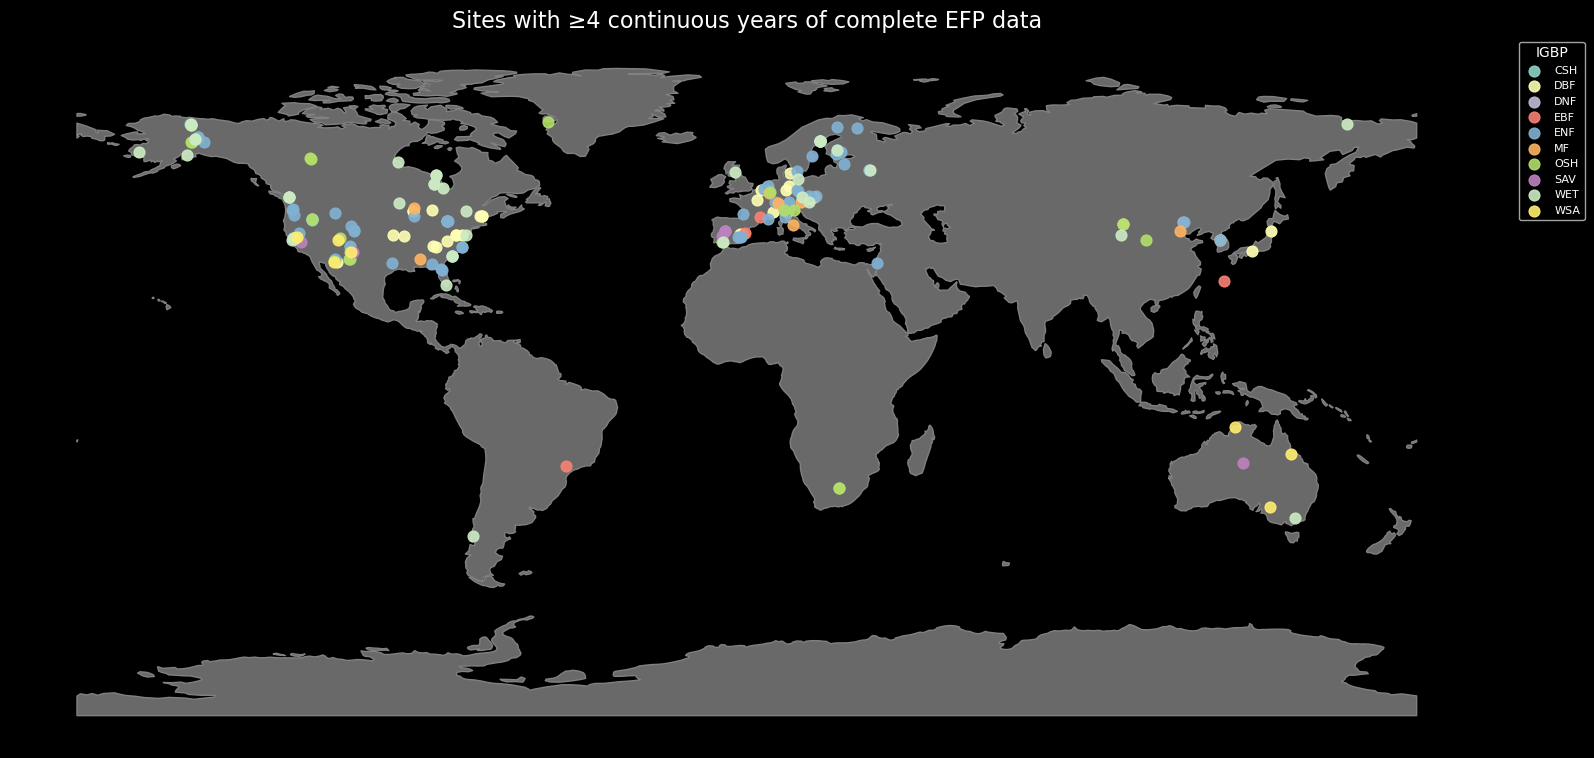

In [12]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
from geodatasets import get_path
import matplotlib.pyplot as plt

base_dir = Path("fluxnet_2017_2025_V02")
out_dir = base_dir / "EFP_outputs_corrected"

# Read EFP subset
efp_final = pd.read_csv(
    out_dir / "ALL_SITES_YEARLY_EFP_complete4continuousYears.csv"
)

# Read metadata
metadata = pd.read_csv(
    base_dir / "fluxnet_site_metadata_clean_with_elevation.csv"
)

# Merge
sites_final = (
    metadata
    .merge(
        efp_final[["SITE_ID"]].drop_duplicates(),
        on="SITE_ID",
        how="inner"
    )
)

print("Number of sites on map:", sites_final["SITE_ID"].nunique())

# Save merged metadata
sites_final.to_csv(
    out_dir / "metadata_sites_complete4continuousYears.csv",
    index=False
)

# Plot world map
world = gpd.read_file(get_path("naturalearth.land"))

plt.style.use("dark_background")

fig, ax = plt.subplots(figsize=(16, 8))

fig.patch.set_facecolor("black")
ax.set_facecolor("black")

world.plot(
    ax=ax,
    color="dimgray",
    edgecolor="gray"
)

for igbp, group in sites_final.groupby("IGBP"):
    ax.scatter(
        group["LOCATION_LONG"],
        group["LOCATION_LAT"],
        s=60,
        alpha=0.9,
        label=igbp
    )

ax.set_title(
    "Sites with ≥4 continuous years of complete EFP data",
    fontsize=16
)

ax.legend(
    title="IGBP",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# Merge EFP table with selected metadata columns only
# ============================================================

meta_subset = metadata[[
    "SITE_ID",
    "IGBP",
    "LOCATION_LAT",
    "LOCATION_LONG",
    "LOCATION_ELEV"
]]

sites_final = efp_final.merge(
    meta_subset,
    on="SITE_ID",
    how="left"
)

# ============================================================
# Check result
# ============================================================

print(sites_final.shape)

display(sites_final.head())

# ============================================================
# Save
# ============================================================

sites_final.to_csv(
    out_dir / "EFP_plus_selected_metadata_complete4continuousYears.csv",
    index=False
)

print("Saved merged table.")

(1180, 24)


,SITE_ID,YEAR,uWUE,WUE,ETmax,precipAvail,Gavail,GSmax,CO2avail,G1,...,Rb,Rbmax,aCUE,TZ,nyears,status,IGBP,LOCATION_LAT,LOCATION_LONG,LOCATION_ELEV
0,AT-Mmg,2021,2.439301,2.874088,0.198979,yes,no,0.007911,yes,2.325367,...,4.979469,6.309289,-0.095422,2.0,1,ok,ENF,47.316563,10.970089,960.0
1,AT-Mmg,2022,2.906286,2.895670,0.204192,yes,yes,0.007394,yes,1.956377,...,NaN,NaN,NaN,2.0,1,ok,ENF,47.316563,10.970089,960.0
2,AT-Mmg,2023,2.732360,2.695378,0.210589,yes,yes,0.008620,yes,2.048815,...,NaN,NaN,NaN,2.0,1,ok,ENF,47.316563,10.970089,960.0
3,AT-Mmg,2024,3.012653,3.099954,0.223068,yes,yes,0.008617,yes,1.898373,...,NaN,NaN,NaN,2.0,1,ok,ENF,47.316563,10.970089,960.0
4,AT-Nsd,2018,1.253188,0.946747,0.234140,yes,yes,0.005695,yes,4.914469,...,2.670853,2.679261,0.055745,2.0,1,ok,WET,47.769140,16.758492,115.0


Saved merged table.


### Merge the meteo and EFPs

In [17]:
from pathlib import Path
import pandas as pd

# ============================================================
# Paths
# ============================================================

base_dir = Path("fluxnet_2017_2025_V02")
out_dir = base_dir / "EFP_outputs_corrected"

# ============================================================
# Read yearly EFP + metadata table
# ============================================================

efp = pd.read_csv(
    out_dir / "EFP_plus_selected_metadata_complete4continuousYears.csv"
)

# ============================================================
# Read monthly meteo table
# ============================================================

meteo = pd.read_csv(
    out_dir / "ALL_SITES_MONTHLY_METEO_corrected.csv"
)

# ============================================================
# Convert monthly meteo to wide format
# ============================================================

# all columns except identifiers
value_cols = [
    c for c in meteo.columns
    if c not in ["SITE_ID", "YEAR", "MONTH"]
]

# pivot wider
meteo_wide = meteo.pivot_table(
    index=["SITE_ID", "YEAR"],
    columns="MONTH",
    values=value_cols
)

# flatten column names
meteo_wide.columns = [
    f"{var}_M{month:02d}"
    for var, month in meteo_wide.columns
]

meteo_wide = meteo_wide.reset_index()

# ============================================================
# Merge with EFP table
# ============================================================

final_df = efp.merge(
    meteo_wide,
    on=["SITE_ID", "YEAR"],
    how="left"
)

# remove columns containing "n_obs"

final_df = final_df.loc[
    :,
    ~final_df.columns.str.contains("n_obs", case=False)
]
# ============================================================
# Save
# ============================================================

final_df.to_csv(
    out_dir / "EFP_metadata_monthlyMeteo_WIDE.csv",
    index=False
)

# optional: save wide meteo separately
meteo_wide.to_csv(
    out_dir / "MONTHLY_METEO_WIDE.csv",
    index=False
)

# ============================================================
# Summary
# ============================================================

print("Final shape:", final_df.shape)
print("Number of sites:", final_df["SITE_ID"].nunique())

display(final_df.head())

Final shape: (1180, 156)
Number of sites: 184


,SITE_ID,YEAR,uWUE,WUE,ETmax,precipAvail,Gavail,GSmax,CO2avail,G1,...,VPD_p95_M03,VPD_p95_M04,VPD_p95_M05,VPD_p95_M06,VPD_p95_M07,VPD_p95_M08,VPD_p95_M09,VPD_p95_M10,VPD_p95_M11,VPD_p95_M12
0,AT-Mmg,2021,2.439301,2.874088,0.198979,yes,no,0.007911,yes,2.325367,...,10.23930,10.61610,13.46680,20.90415,16.6432,17.62215,14.74830,9.83215,4.94910,3.99165
1,AT-Mmg,2022,2.906286,2.895670,0.204192,yes,yes,0.007394,yes,1.956377,...,13.01310,12.78190,20.58420,24.53820,26.7175,21.14675,11.10100,9.58630,6.73715,3.56460
2,AT-Mmg,2023,2.732360,2.695378,0.210589,yes,yes,0.008620,yes,2.048815,...,8.89495,9.41095,15.61420,23.78370,22.7774,23.44365,17.26095,14.54050,4.84630,5.32190
3,AT-Mmg,2024,3.012653,3.099954,0.223068,yes,yes,0.008617,yes,1.898373,...,9.07745,18.69910,14.32515,18.75940,18.8256,19.91175,13.24215,8.12350,6.18130,4.47830
4,AT-Nsd,2018,1.253188,0.946747,0.234140,yes,yes,0.005695,yes,4.914469,...,5.30595,16.26330,15.12360,17.22025,22.5340,27.96490,17.79530,12.04240,4.61730,4.23555
